# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")


# Single label classification to multi label classification

In [1]:
from typing import List, Tuple
import numpy as np

def label_to_tuple(label: int) -> Tuple[bool, bool, bool, bool]:
    '''
    Convert a class label to a 4d vector binary encoding the brake status.
    Input: class label (0-11).
    Output: (front_left, front_right, rear_left, rear_right), where True indicates an irregularity.
    '''
    match label:
        case 0: return (False, False, False, False)
        case 1: return (False, False, True, False)
        case 2: return (False, False, False, True)
        case 3: return (False, False, True, True)
        case 4: return (True, False, False, False)
        case 5: return (False, True, False, False)
        case 6: return (True, True, False, False)
        case 7: return (True, False, True, False)
        case 8: return (False, True, False, True)
        case 9: return (True, False, False, True)
        case 10: return (False, True, True, False)
        case 11: return (True, True, True, True)
    raise ValueError(f"Invalid label: {label}. Expected a value between 0 and 11.")

def tuple_to_label(tup: Tuple[bool, bool, bool, bool]) -> int:
    '''
    Convert a 4d tuple binary encoding the brake status to a class label.
    Input: (front_left, front_right, rear_left, rear_right), where True indicates an irregularity.
    Output: class label (0-11).
    '''
    match tup:
        case (False, False, False, False): return 0
        case (False, False, True, False): return 1
        case (False, False, False, True): return 2
        case (False, False, True, True): return 3
        case (True, False, False, False): return 4
        case (False, True, False, False): return 5
        case (True, True, False, False): return 6
        case (True, False, True, False): return 7
        case (False, True, False, True): return 8
        case (True, False, False, True): return 9
        case (False, True, True, False): return 10
        case (True, True, True, True): return 11
    raise ValueError(f"Invalid tuple: {tup}. Expected a tuple of 4 booleans.")

# Load libraries, set seed, preprocessing and augmentation

C:\Users\anuhe\AppData\Local\Temp\ipykernel_19228\129838448.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_19228\129838448.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct

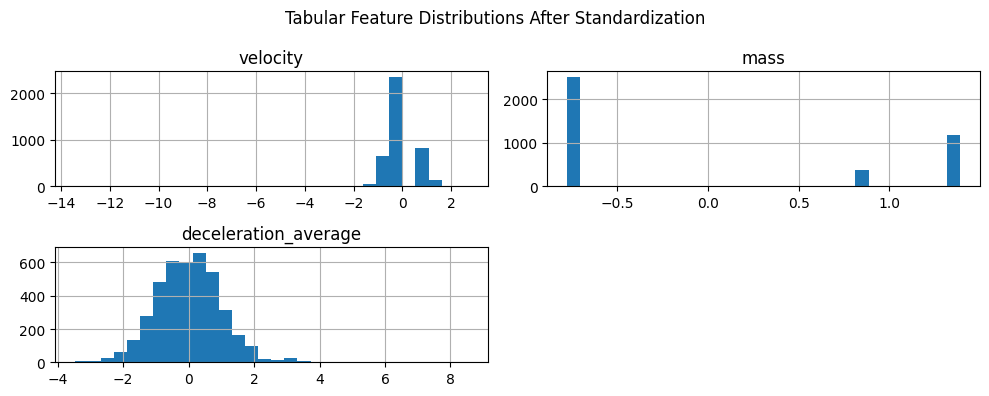

          Component            Shape
0       Sensor Data  (14998, 128, 6)
1  Tabular Features       (14998, 3)
2            Labels       (14998, 4)


In [ ]:
import torch
import pickle
import numpy as np
import random
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
import matplotlib.pyplot as plt
from typing import Tuple

# --- Set random seed ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# --- Label conversion ---
def label_to_tuple(label: int) -> Tuple[bool, bool, bool, bool]:
    match label:
        case 0: return (False, False, False, False)
        case 1: return (False, False, True, False)
        case 2: return (False, False, False, True)
        case 3: return (False, False, True, True)
        case 4: return (True, False, False, False)
        case 5: return (False, True, False, False)
        case 6: return (True, True, False, False)
        case 7: return (True, False, True, False)
        case 8: return (False, True, False, True)
        case 9: return (True, False, False, True)
        case 10: return (False, True, True, False)
        case 11: return (True, True, True, True)
    raise ValueError(f"Invalid label: {label}. Expected a value between 0 and 11.")

# --- Load data ---
# def load_pickle(path):
#     with open(path, 'rb') as f:
#         return pickle.load(f)
#
# train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
# test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")

train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

# --- KNN Imputation for test_data ---
combined = pd.concat([train_data.drop(columns=["label"]), test_data.drop(columns=["label"])]).reset_index(drop=True)
knn_imputer = KNNImputer(n_neighbors=5)
combined_imputed = knn_imputer.fit_transform(combined.select_dtypes(include=[np.number]))

# Restore imputed test_data
combined_columns = combined.select_dtypes(include=[np.number]).columns
test_data.loc[:, combined_columns] = combined_imputed[len(train_data):, :]

# --- Feature Splitting ---
X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)

X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

# --- Tabular Standardization ---
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

# --- Visualize standardized tabular data ---
tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()

# --- Sensor Standardization ---
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

sensor_scaler = RobustScaler()
flat_train_scaled = sensor_scaler.fit_transform(flat_train)
flat_test_scaled = sensor_scaler.transform(flat_test)

X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)

# --- Convert to Multi-label using DataFrames ---
y_train_multi = y_train.apply(label_to_tuple)
y_test_multi = y_test.apply(label_to_tuple)

y_train_multi_df = pd.DataFrame(y_train_multi.tolist(), columns=["front_left", "front_right", "rear_left", "rear_right"])
y_test_multi_df = pd.DataFrame(y_test_multi.tolist(), columns=["front_left", "front_right", "rear_left", "rear_right"])

y_train_multi_np = y_train_multi_df.values.astype(np.float32)
y_test_multi_np = y_test_multi_df.values.astype(np.float32)

# --- Data Augmentation ---
def augment_dataset(X_sensor, X_tab, y, target_count=500):
    y_tuples = [tuple(row) for row in y]
    unique_labels, counts = np.unique(y_tuples, axis=0, return_counts=True)

    X_sensor_aug_all, X_tab_aug_all, y_aug_all = [], [], []

    for label, count in zip(unique_labels, counts):
        n_needed = target_count - count
        if n_needed <= 0:
            continue

        mask = np.all(y == label, axis=1)
        idx = np.where(mask)[0]

        for _ in range(n_needed):
            i = np.random.choice(idx)
            sensor_sample = X_sensor[i].copy()
            sensor_sample += np.random.normal(0, 0.01, sensor_sample.shape)
            sensor_sample *= np.random.uniform(0.9, 1.1, (1, sensor_sample.shape[1]))
            segs = np.array_split(sensor_sample, 4)
            np.random.shuffle(segs)
            sensor_sample = np.concatenate(segs, axis=0)

            tab_sample = X_tab[i].copy()
            tab_sample += np.random.normal(0, 0.05, tab_sample.shape)

            X_sensor_aug_all.append(sensor_sample)
            X_tab_aug_all.append(tab_sample)
            y_aug_all.append(label)

    if not X_sensor_aug_all:
        return X_sensor, X_tab, y

    return (
        np.concatenate([X_sensor, np.array(X_sensor_aug_all)]),
        np.concatenate([X_tab, np.array(X_tab_aug_all)]),
        np.concatenate([y, np.array(y_aug_all, dtype=np.float32)])
    )

# --- Apply augmentation ---
X_train_sensor_balanced, X_train_tab_balanced, y_train_balanced = augment_dataset(
    X_sensor=X_train_sensor_clipped,
    X_tab=X_train_tab_scaled,
    y=y_train_multi_np,
    target_count=1200
)

# --- Summary ---
sensor_shape = X_train_sensor_balanced.shape
tabular_shape = X_train_tab_balanced.shape
label_shape = y_train_balanced.shape

summary_df = pd.DataFrame({
    "Component": ["Sensor Data", "Tabular Features", "Labels"],
    "Shape": [sensor_shape, tabular_shape, label_shape]
})

print(summary_df)


In [12]:
print(y_train_multi_df.head())


   front_left  front_right  rear_left  rear_right
0       False        False       True        True
1       False        False       True        True
2       False        False       True        True
3       False        False       True        True
4       False        False       True        True


# Model architecture

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import pickle
import random
import json

# --- Reproducibility ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# --- Dataset Class ---
class SensorDataset(Dataset):
    def __init__(self, sensor_seqs, tabular_feats, labels):
        self.sensor_seqs = torch.tensor(sensor_seqs, dtype=torch.float32)
        self.tabular_feats = torch.tensor(tabular_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        


    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_seqs[idx], self.tabular_feats[idx], self.labels[idx]

# --- Transformer Classifier for Multi-label ---
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=6, seq_len=128, n_heads=4, num_layers=2,
                 d_model=64, dim_feedforward=128, tabular_dim=3,
                 tab_hidden_dim=32, output_dim=4, dropout=0.3):
        super(TransformerClassifier, self).__init__()

        self.input_proj = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model + tab_hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_seq, x_tab):
        x = self.input_proj(x_seq)
        x = self.transformer_encoder(x)
        x_last = x[:, -1, :]
        tab_out = self.tabular_net(x_tab)
        combined = torch.cat((x_last, tab_out), dim=1)
        return self.classifier(combined)

# --- Training & Evaluation ---
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_seq, x_tab, y in dataloader:
        x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x_seq, x_tab)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_metrics(model, dataloader, device, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab = x_seq.to(device), x_tab.to(device)
            logits = model(x_seq, x_tab)
            preds = (torch.sigmoid(logits) >= threshold).int()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    return {
        'f1_micro': f1_score(all_labels, all_preds, average='micro'),
        'f1_macro': f1_score(all_labels, all_preds, average='macro'),
        'subset_accuracy': accuracy_score(all_labels, all_preds),
        'f1_per_label': f1_score(all_labels, all_preds, average=None)
    }

# --- Hyperparameter Space ---
param_space = {
    'hidden_dim': [64, 128],
    'num_layers': [1, 2, 3],
    'dropout': [0.1, 0.3, 0.5],
    'tab_hidden_dim': [16, 32, 64],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128]
}

def sample_hyperparams(param_space):
    return {k: random.choice(v) for k, v in param_space.items()}

# --- Main Random Search CV Loop ---
def run_random_search_cv(sensor_data, tab_data, labels, num_trials=10, num_epochs=10, device='cpu'):
    best_f1 = -1
    best_params = None
    best_model_state = None

    for trial in range(num_trials):
        print(f"\nTrial {trial+1}/{num_trials}")
        params = sample_hyperparams(param_space)
        print(" Hyperparams:", params)

        all_f1_scores = []
        for split in range(5):
            X_tr, X_val, T_tr, T_val, y_tr, y_val = train_test_split(
                sensor_data, tab_data, labels,
                test_size=0.2, random_state=split + trial * 100
            )

            train_ds = SensorDataset(X_tr, T_tr, y_tr)
            val_ds = SensorDataset(X_val, T_val, y_val)
            train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)

            model = TransformerClassifier(
                input_dim=sensor_data.shape[2],
                seq_len=sensor_data.shape[1],
                n_heads=4,
                num_layers=params['num_layers'],
                d_model=params['hidden_dim'],
                dim_feedforward=128,
                tabular_dim=tab_data.shape[1],
                tab_hidden_dim=params['tab_hidden_dim'],
                output_dim=labels.shape[1],
                dropout=params['dropout']
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
            criterion = nn.BCEWithLogitsLoss()

            best_val_f1 = 0
            patience = 5
            patience_counter = 0

            for epoch in range(num_epochs):
                train_one_epoch(model, train_loader, optimizer, criterion, device)
                metrics = evaluate_metrics(model, val_loader, device)
                f1 = metrics['f1_micro']

                if f1 > best_val_f1:
                    best_val_f1 = f1
                    best_epoch_model = model.state_dict()
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping at epoch {epoch+1}")
                        break

            model.load_state_dict(best_epoch_model)
            metrics = evaluate_metrics(model, val_loader, device)
            all_f1_scores.append(metrics['f1_micro'])

        avg_f1 = np.mean(all_f1_scores)
        print(f" Average Micro F1 score: {avg_f1:.4f}")

        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_params = params
            best_model_state = model.state_dict()
            torch.save(best_model_state, "BEST_TRANSFORMER_MULTILABEL.pth")
            with open("BEST_TRANSFORMER_MULTILABEL_PARAMS.json", "w") as f:
                json.dump(best_params, f, indent=4)
            with open("BEST_TRANSFORMER_MULTILABEL_PARAMS.pickle", "wb") as f:
                pickle.dump(best_params, f)

    print("\n Best Hyperparameters Found:")
    print(best_params)
    print(f"Best Micro F1: {best_f1:.4f}")
    return best_params, best_f1, best_model_state


# Train the model

In [ ]:
# Ensure device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_params, best_f1, best_model_state = run_random_search_cv(
    sensor_data=X_train_sensor_balanced,
    tab_data=X_train_tab_balanced,
    labels=y_train_balanced,  
    num_trials=2,
    num_epochs=10,
    device=device
)




🎯 Trial 1/2
🔧 Hyperparams: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.1, 'tab_hidden_dim': 64, 'learning_rate': 0.001, 'batch_size': 128}
⏹️ Early stopping at epoch 10
 Average Micro F1 score: 0.9991

🎯 Trial 2/2
🔧 Hyperparams: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.3, 'tab_hidden_dim': 16, 'learning_rate': 0.0001, 'batch_size': 32}
 Average Micro F1 score: 0.9990

🥇 Best Hyperparameters Found:
{'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.1, 'tab_hidden_dim': 64, 'learning_rate': 0.001, 'batch_size': 128}
Best Micro F1: 0.9991


# Load the data

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

# Load best hyperparameters
with open("BEST_TRANSFORMER_MULTILABEL_PARAMS.json", "r") as f:
    best_params = json.load(f)

def evaluate_on_test_set(model_path, test_sensor, test_tab, test_labels, device='cpu'):
    # Load best model
    model = TransformerClassifier(
        input_dim=test_sensor.shape[2],
        seq_len=test_sensor.shape[1],
        n_heads=4,
        num_layers=best_params["num_layers"],
        d_model=best_params["hidden_dim"],
        dim_feedforward=128,
        tabular_dim=test_tab.shape[1],
        tab_hidden_dim=best_params["tab_hidden_dim"],
        output_dim=test_labels.shape[1],
        dropout=best_params["dropout"]
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Prepare DataLoader
    test_dataset = SensorDataset(test_sensor, test_tab, test_labels)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # Collect predictions
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in test_loader:
            x_seq, x_tab = x_seq.to(device), x_tab.to(device)
            logits = model(x_seq, x_tab)
            preds = (torch.sigmoid(logits) >= 0.5).int()
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # --- Metrics ---
    f1_micro = f1_score(all_labels, all_preds, average='micro')
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_per_label = f1_score(all_labels, all_preds, average=None)
    subset_acc = accuracy_score(all_labels, all_preds)

    print("\n Test Set Evaluation")
    print(f"Subset Accuracy    : {subset_acc:.4f}")
    print(f"F1 Score (Micro)   : {f1_micro:.4f}")
    print(f"F1 Score (Macro)   : {f1_macro:.4f}")
    print(f"F1 Per Label       : {np.round(f1_per_label, 4)}")

    # --- Confusion matrices (one per label) ---
    brake_labels = ['front_left', 'front_right', 'rear_left', 'rear_right']
    for i in range(4):
        cm = confusion_matrix(all_labels[:, i], all_preds[:, i])
        disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
        disp.plot(cmap='Blues')
        plt.title(f'Confusion Matrix: {brake_labels[i]}')
        plt.grid(False)
        plt.show()


# Evaluate the test


 Test Set Evaluation
Subset Accuracy    : 0.4456
F1 Score (Micro)   : 0.1909
F1 Score (Macro)   : 0.1801
F1 Per Label       : [0.3088 0.1176 0.1351 0.1588]


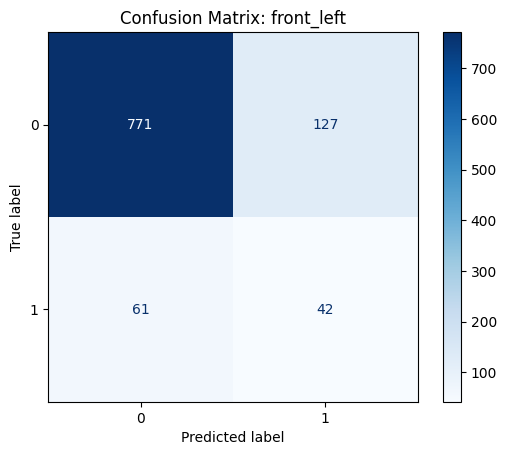

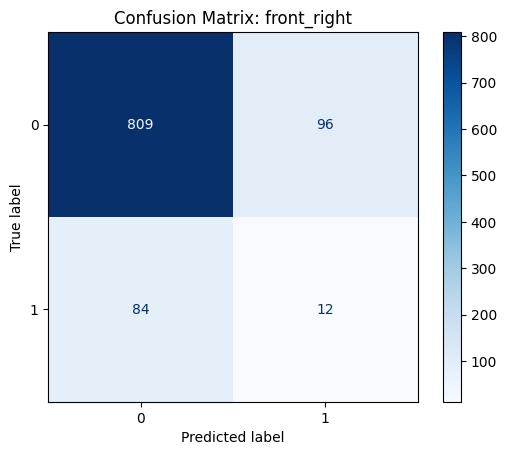

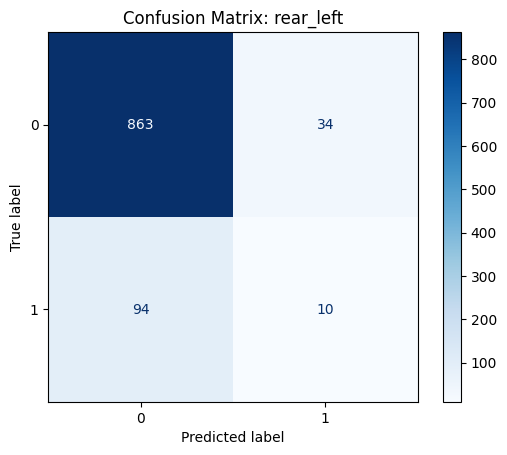

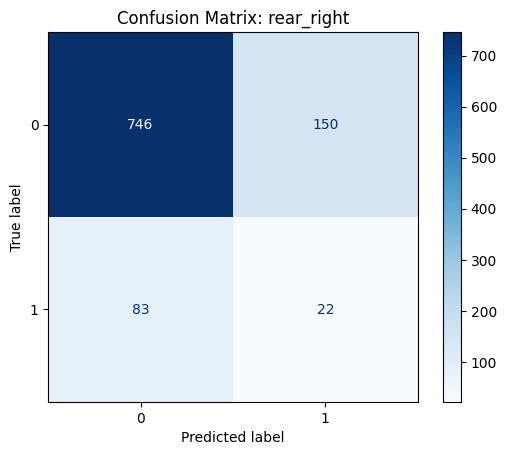

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

evaluate_on_test_set(
    model_path="BEST_TRANSFORMER_MULTILABEL.pth",
    test_sensor=X_test_sensor_scaled,
    test_tab=X_test_tab_scaled,
    test_labels=y_test_multi_np,
    device=device
)
